# 01 — Exploratory Data Analysis

Olist Brazilian E-Commerce dataset — 100k real orders (2016–2018).

**Contents:**
1. Dataset overview & data quality
2. Order volume patterns (time, geography)
3. Revenue analysis by state and category
4. Delivery performance baseline
5. Customer behaviour
6. Review analysis

In [1]:
import sys, os
# Make project root importable regardless of where Jupyter is launched from
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
print("Project root added to path ✓")

Project root added to path ✓


In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from data_loader import OlistLoader

pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (12, 5)
sns.set_theme(style="darkgrid", palette="muted")

loader = OlistLoader()
print(loader.summary())

2026-03-06 20:35:50.918 | INFO     | data_loader:__init__:65 - OlistLoader ready — 9/9 CSV files found in C:\Users\luizg\Downloads\ProjetoGithub\olist-ecommerce-platform\data
2026-03-06 20:35:51.219 | DEBUG    | data_loader:_read:295 - Loaded orders: 99,441 rows from olist_orders_dataset.csv


{'total_orders': 99441, 'delivered': 96478, 'date_range': ('2016-09-04', '2018-10-17'), 'files_loaded': 9}


## 1. Dataset Overview

In [3]:
orders    = loader.orders()
items     = loader.order_items()
payments  = loader.order_payments()
reviews   = loader.order_reviews()
customers = loader.customers()
sellers   = loader.sellers()
products  = loader.products()

datasets = {
    "orders": orders, "items": items, "payments": payments,
    "reviews": reviews, "customers": customers,
    "sellers": sellers, "products": products,
}

summary = pd.DataFrame([
    {"dataset": k, "rows": len(v), "columns": len(v.columns),
     "null_pct": round(v.isnull().mean().mean() * 100, 2)}
    for k, v in datasets.items()
])
print(summary.to_string(index=False))

2026-03-06 20:35:51.581 | DEBUG    | data_loader:_read:295 - Loaded order_items: 112,650 rows from olist_order_items_dataset.csv
2026-03-06 20:35:51.660 | DEBUG    | data_loader:_read:295 - Loaded order_payments: 103,886 rows from olist_order_payments_dataset.csv
2026-03-06 20:35:51.945 | DEBUG    | data_loader:_read:295 - Loaded order_reviews: 99,224 rows from olist_order_reviews_dataset.csv
2026-03-06 20:35:52.074 | DEBUG    | data_loader:_read:295 - Loaded customers: 99,441 rows from olist_customers_dataset.csv
2026-03-06 20:35:52.081 | DEBUG    | data_loader:_read:295 - Loaded sellers: 3,095 rows from olist_sellers_dataset.csv
2026-03-06 20:35:52.116 | DEBUG    | data_loader:_read:295 - Loaded products: 32,951 rows from olist_products_dataset.csv
2026-03-06 20:35:52.119 | DEBUG    | data_loader:_read:295 - Loaded product_category: 71 rows from product_category_name_translation.csv


  dataset   rows  columns  null_pct
   orders  99441        8      0.62
    items 112650        7      0.00
 payments 103886        5      0.00
  reviews  99224        7     21.01
customers  99441        5      0.00
  sellers   3095        4      0.00
 products  32951       10      0.93


## 2. Order Volume Over Time

In [4]:
df = loader.order_features()

monthly = (
    df.groupby("purchase_ym")
    .agg(order_count=("order_id", "count"), gmv=("payment_value", "sum"))
    .reset_index()
)

fig = make_subplots(rows=2, cols=1, subplot_titles=["Monthly Order Volume", "Monthly GMV (R$)"])
fig.add_trace(go.Bar(x=monthly["purchase_ym"], y=monthly["order_count"], name="Orders"), row=1, col=1)
fig.add_trace(go.Scatter(x=monthly["purchase_ym"], y=monthly["gmv"], fill="tozeroy", name="GMV"), row=2, col=1)
fig.update_layout(height=600, showlegend=False, title_text="Olist Order Volume & Revenue Over Time")
fig.show()

print(f"Peak month: {monthly.loc[monthly['order_count'].idxmax(), 'purchase_ym']}  ({monthly['order_count'].max():,} orders)")
print(f"Total GMV: R$ {monthly['gmv'].sum():,.0f}")

2026-03-06 20:35:52.205 | INFO     | data_loader:order_features:129 - Building order_features table...
2026-03-06 20:36:10.277 | INFO     | data_loader:order_features:221 - order_features: 99,441 rows, 34 columns


Peak month: 2017-11  (7,544 orders)
Total GMV: R$ 16,008,872


## 3. Geographic Distribution

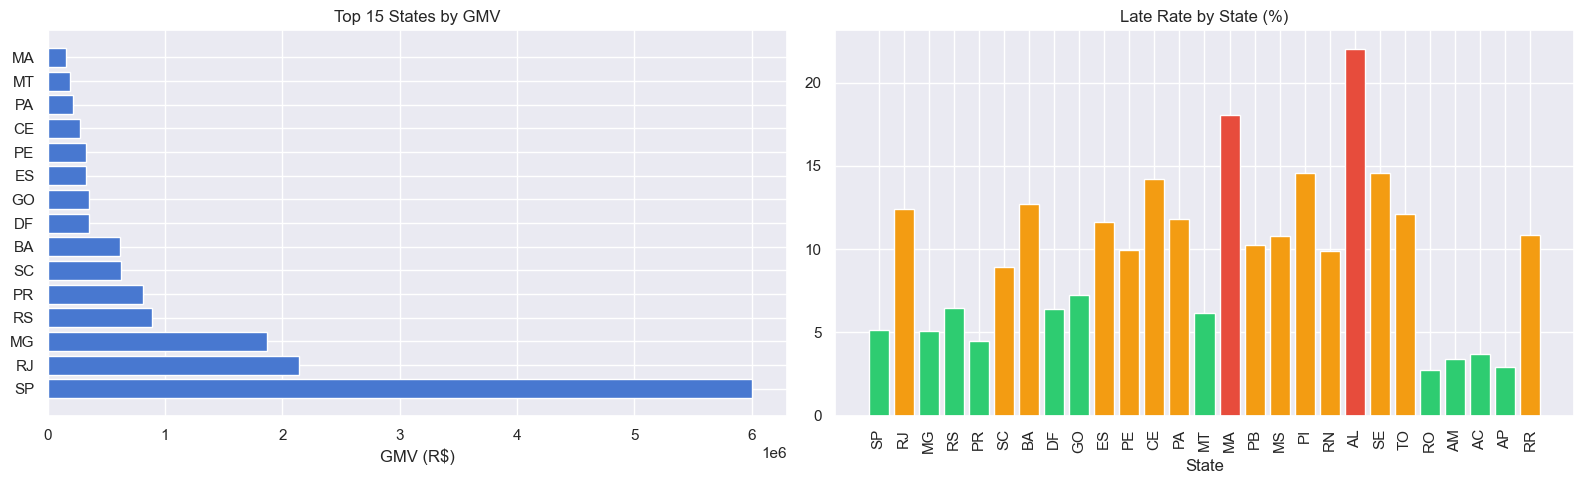


Top 5 states by GMV:
customer_state  order_count        gmv  late_rate
            SP        41746 5998226.96       0.05
            RJ        12852 2144379.69       0.12
            MG        11635 1872257.26       0.05
            RS         5466  890898.54       0.06
            PR         5045  811156.38       0.04


In [5]:
state_orders = (
    df.groupby("customer_state")
    .agg(
        order_count=("order_id",       "count"),
        gmv        =("payment_value",  "sum"),
        avg_review =("review_score",   "mean"),
        late_rate  =("is_late",        "mean"),
    )
    .reset_index()
    .sort_values("gmv", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(state_orders["customer_state"].head(15), state_orders["gmv"].head(15))
axes[0].set_title("Top 15 States by GMV")
axes[0].set_xlabel("GMV (R$)")

colors = ["#e74c3c" if x > 0.15 else "#f39c12" if x > 0.08 else "#2ecc71"
          for x in state_orders["late_rate"]]
axes[1].bar(state_orders["customer_state"], state_orders["late_rate"] * 100, color=colors)
axes[1].set_title("Late Rate by State (%)")
axes[1].set_xlabel("State")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

print("\nTop 5 states by GMV:")
print(state_orders.head()[["customer_state", "order_count", "gmv", "late_rate"]].to_string(index=False))

## 4. Revenue by Product Category

In [6]:
cat_revenue = (
    df.groupby("main_category")
    .agg(
        order_count=("order_id",      "count"),
        gmv        =("payment_value", "sum"),
        avg_ticket =("payment_value", "mean"),
        late_rate  =("is_late",       "mean"),
    )
    .reset_index()
    .sort_values("gmv", ascending=False)
    .head(20)
)

fig = px.bar(
    cat_revenue, x="gmv", y="main_category", orientation="h",
    color="late_rate", color_continuous_scale="RdYlGn_r",
    title="Top 20 Categories — GMV vs Late Rate",
    labels={"gmv": "GMV (R$)", "main_category": "", "late_rate": "Late Rate"},
)
fig.update_layout(height=600, yaxis={"categoryorder": "total ascending"})
fig.show()

## 5. Delivery Performance

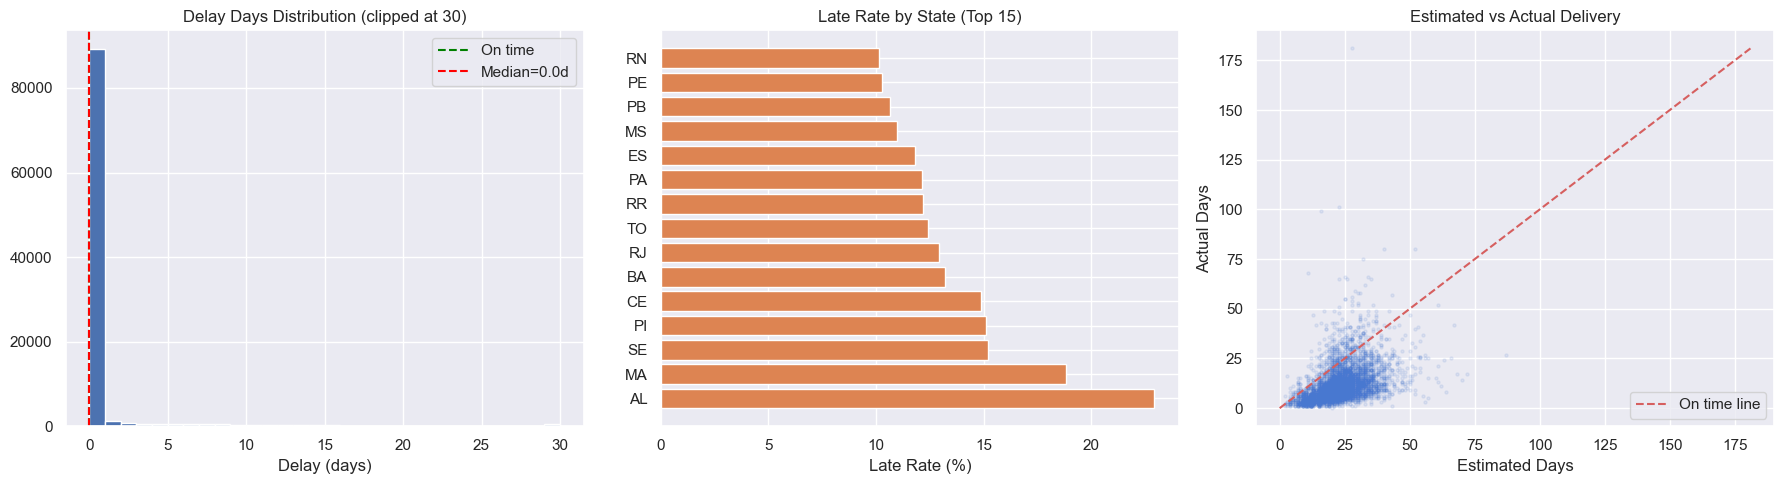

Overall late rate: 7.6%
Median delay (late orders only): 6.0 days


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

delivered = df[df["order_status"] == "delivered"].dropna(subset=["delay_days"])
axes[0].hist(delivered["delay_days"].clip(0, 30), bins=30, color="#4C72B0", edgecolor="white")
axes[0].set_title("Delay Days Distribution (clipped at 30)")
axes[0].set_xlabel("Delay (days)")
axes[0].axvline(0, color="green", linestyle="--", label="On time")
axes[0].axvline(delivered["delay_days"].median(), color="red", linestyle="--",
                label=f"Median={delivered['delay_days'].median():.1f}d")
axes[0].legend()

state_late = (
    delivered.groupby("customer_state")["is_late"].mean()
    .sort_values(ascending=False).head(15)
)
axes[1].barh(state_late.index, state_late.values * 100, color="#DD8452")
axes[1].set_title("Late Rate by State (Top 15)")
axes[1].set_xlabel("Late Rate (%)")

sample = delivered.dropna(subset=["estimated_days", "actual_days"]).sample(min(5000, len(delivered)), random_state=42)
axes[2].scatter(sample["estimated_days"], sample["actual_days"], alpha=0.1, s=5)
lim = max(sample["estimated_days"].max(), sample["actual_days"].max())
axes[2].plot([0, lim], [0, lim], "r--", label="On time line")
axes[2].set_xlabel("Estimated Days")
axes[2].set_ylabel("Actual Days")
axes[2].set_title("Estimated vs Actual Delivery")
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Overall late rate: {delivered['is_late'].mean():.1%}")
print(f"Median delay (late orders only): {delivered[delivered['is_late']==1]['delay_days'].median():.1f} days")

## 6. Customer Behaviour & Reviews

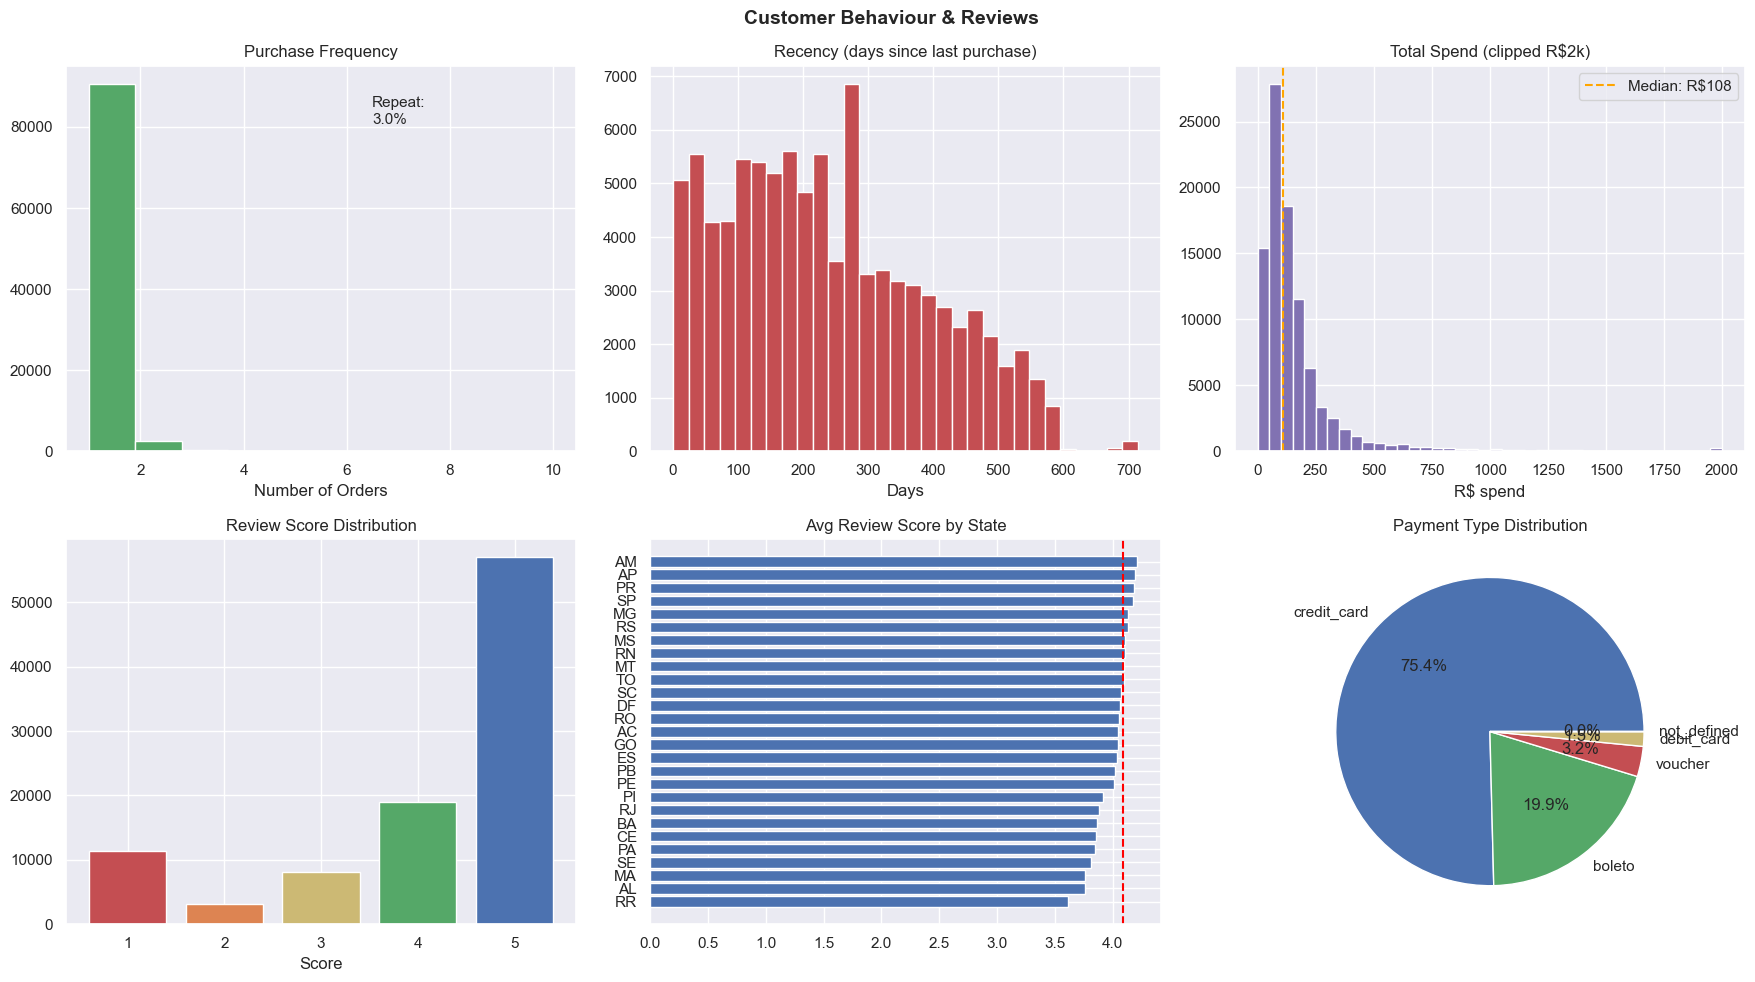

Total unique customers: 93,358
Repeat purchase rate:   3.0%
Median total spend:     R$ 107.78
Average review score:   4.09 / 5


In [8]:
rfm = loader.customer_rfm()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Frequency
axes[0,0].hist(rfm["frequency"].clip(0, 10), bins=10, color="#55A868", edgecolor="white")
axes[0,0].set_title("Purchase Frequency")
axes[0,0].set_xlabel("Number of Orders")
repeat_pct = (rfm["frequency"] > 1).mean()
axes[0,0].text(0.6, 0.85, f"Repeat:\n{repeat_pct:.1%}", transform=axes[0,0].transAxes, fontsize=11)

# Recency
axes[0,1].hist(rfm["recency_days"].clip(0, 730), bins=30, color="#C44E52", edgecolor="white")
axes[0,1].set_title("Recency (days since last purchase)")
axes[0,1].set_xlabel("Days")

# Spend
axes[0,2].hist(rfm["total_spend"].clip(0, 2000), bins=40, color="#8172B2", edgecolor="white")
axes[0,2].set_title("Total Spend (clipped R$2k)")
axes[0,2].set_xlabel("R$ spend")
axes[0,2].axvline(rfm["total_spend"].median(), color="orange", linestyle="--",
                   label=f"Median: R${rfm['total_spend'].median():.0f}")
axes[0,2].legend()

# Review score distribution
score_dist = df["review_score"].value_counts().sort_index()
colors = ["#C44E52","#DD8452","#CCB974","#55A868","#4C72B0"]
axes[1,0].bar(score_dist.index, score_dist.values, color=colors)
axes[1,0].set_title("Review Score Distribution")
axes[1,0].set_xlabel("Score")

# Avg review by state
state_review = df.groupby("customer_state")["review_score"].mean().sort_values()
axes[1,1].barh(state_review.index, state_review.values, color="#4C72B0")
axes[1,1].set_title("Avg Review Score by State")
axes[1,1].axvline(df["review_score"].mean(), color="red", linestyle="--")

# Payment type
pay_counts = df["main_payment_type"].value_counts()
axes[1,2].pie(pay_counts.values, labels=pay_counts.index, autopct="%1.1f%%",
               colors=["#4C72B0","#55A868","#C44E52","#CCB974"])
axes[1,2].set_title("Payment Type Distribution")

plt.suptitle("Customer Behaviour & Reviews", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Total unique customers: {len(rfm):,}")
print(f"Repeat purchase rate:   {repeat_pct:.1%}")
print(f"Median total spend:     R$ {rfm['total_spend'].median():.2f}")
print(f"Average review score:   {df['review_score'].mean():.2f} / 5")